Sample records:
      MODELYEAR       MAKE                 MODEL    VEHICLECLASS  ENGINESIZE  \
36        2014       AUDI  A8L TDI CLEAN DIESEL       FULL-SIZE         3.0   
419       2014       FORD               MUSTANG      SUBCOMPACT         5.0   
192       2014  CHEVROLET             CAMARO SS         COMPACT         6.2   
894       2014    PORSCHE             CAYENNE S  SUV - STANDARD         4.8   
324       2014      DODGE       DURANGO AWD FFV  SUV - STANDARD         3.6   

     CYLINDERS TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  \
36           6          AS8        D                  10.1   
419          8           M6        X                  15.4   
192          8           M6        Z                  15.0   
894          8           A8        Z                  15.0   
324          6           A8        X                  13.9   

     FUELCONSUMPTION_HWY  FUELCONSUMPTION_COMB  FUELCONSUMPTION_COMB_MPG  \
36                   6.5                   8.5             

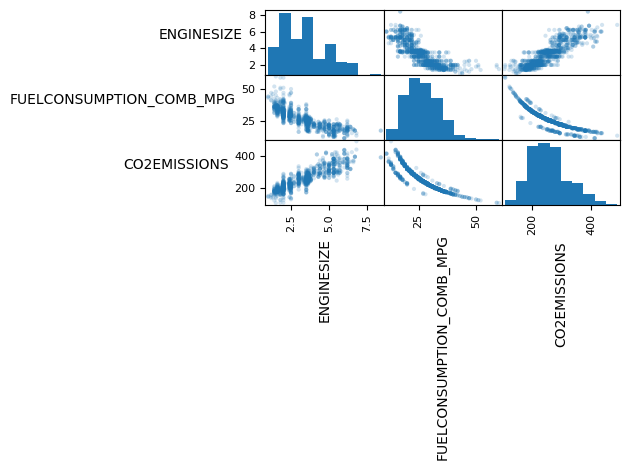


Standardized feature summary:
              0        1
count  1067.00  1067.00
mean      0.00    -0.00
std       1.00     1.00
min      -1.66    -2.07
25%      -0.95    -0.73
50%       0.04    -0.06
75%       0.67     0.61
max       3.57     4.50

Standardized Model Coefficients:
 [[ 25.27339614 -37.4381472 ]]
Intercept: [256.29072488]

Original Scale Coefficients:
 [[17.8581369  -5.01502179]]
Original Scale Intercept: [329.1363967]


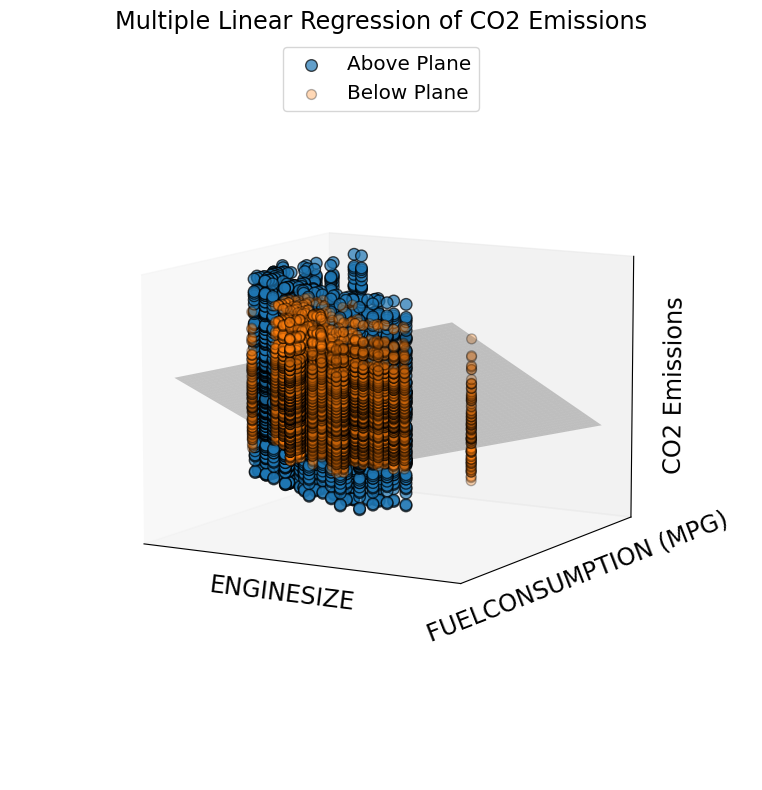

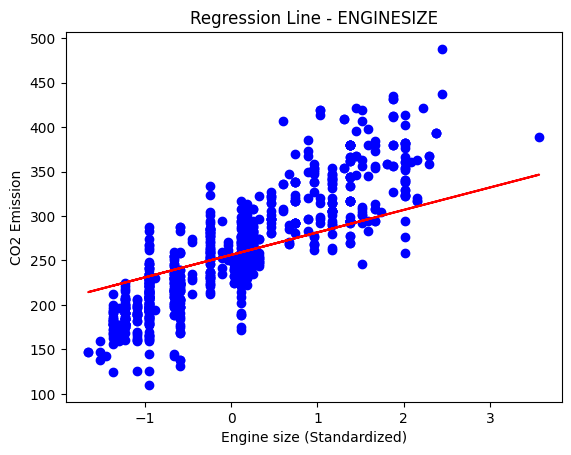

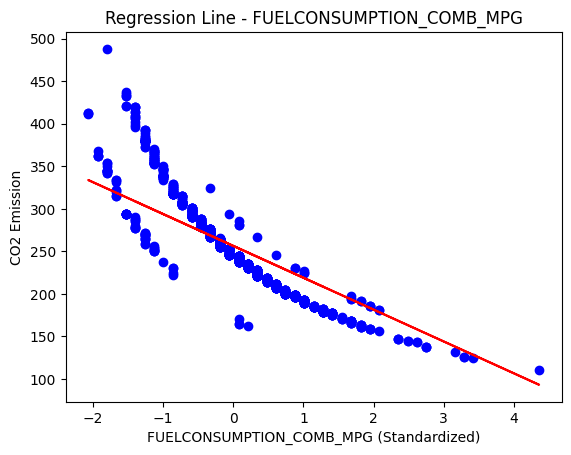


Simple Regression (ENGINESIZE):
Coefficient: [[55.18408797]]
Intercept: [256.77183014]


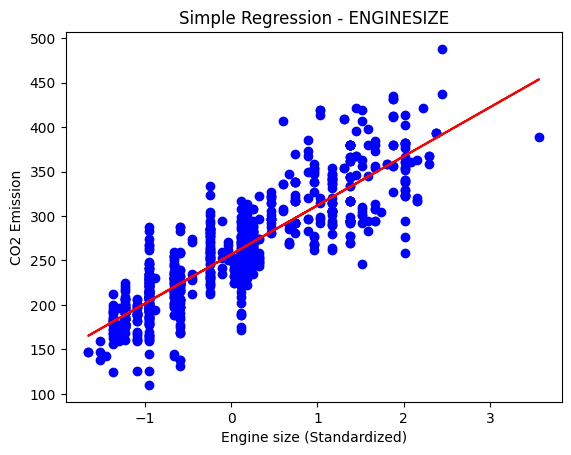

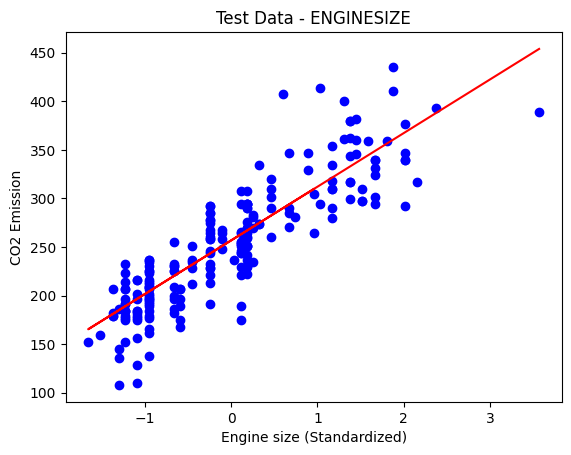


Simple Regression (FUELCONSUMPTION_COMB_MPG):
Coefficient: [[-58.51827989]]
Intercept: [256.09392179]


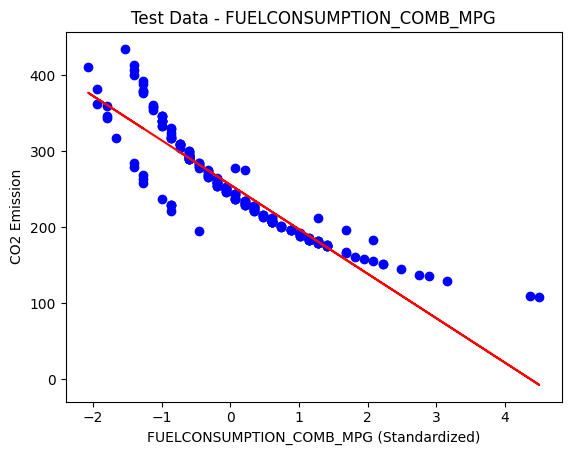

In [1]:
# ----------------------------------------
# 1. Import Required Libraries
# ----------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import preprocessing, linear_model
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D

# For Jupyter Notebook: display plots inline
%matplotlib inline

# ----------------------------------------
# 2. Load and Preview Dataset
# ----------------------------------------
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df = pd.read_csv(url)

# Preview random records and summary stats
print("Sample records:\n", df.sample(5))
print("\nDataset summary:\n", df.describe())

# ----------------------------------------
# 3. Drop Unnecessary Columns
# ----------------------------------------
df = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE'], axis=1)

# Check correlation between remaining features
print("\nCorrelation matrix:\n", df.corr())

# Drop redundant or less relevant features
df = df.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB'], axis=1)

# ----------------------------------------
# 4. Visualize Feature Relationships
# ----------------------------------------
print("\nData preview after feature selection:\n", df.head(9))

axes = pd.plotting.scatter_matrix(df, alpha=0.2)
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

# ----------------------------------------
# 5. Prepare Features and Normalize
# ----------------------------------------
X = df.iloc[:, [0, 1]].to_numpy()  # ENGINESIZE, FUELCONSUMPTION_COMB_MPG
y = df.iloc[:, [2]].to_numpy()    # CO2EMISSIONS

std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(X)

print("\nStandardized feature summary:\n", pd.DataFrame(X_std).describe().round(2))

# ----------------------------------------
# 6. Train-Test Split
# ----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.2, random_state=42)

# ----------------------------------------
# 7. Train Multiple Linear Regression Model
# ----------------------------------------
regressor = linear_model.LinearRegression()
regressor.fit(X_train, y_train)

coef_ = regressor.coef_
intercept_ = regressor.intercept_
print("\nStandardized Model Coefficients:\n", coef_)
print("Intercept:", intercept_)

# Convert coefficients back to original feature space
means_ = std_scaler.mean_
std_devs_ = np.sqrt(std_scaler.var_)
coef_original = coef_ / std_devs_
intercept_original = intercept_ - np.sum((means_ * coef_) / std_devs_)

print("\nOriginal Scale Coefficients:\n", coef_original)
print("Original Scale Intercept:", intercept_original)

# ----------------------------------------
# 8. 3D Visualization of Regression Plane
# ----------------------------------------
X1 = X_test[:, 0]
X2 = X_test[:, 1]

x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100),
                               np.linspace(X2.min(), X2.max(), 100))
y_surf = intercept_ + coef_[0, 0] * x1_surf + coef_[0, 1] * x2_surf

y_pred = regressor.predict(X_test)
above_plane = (y_test >= y_pred)[:, 0]
below_plane = (y_test < y_pred)[:, 0]

fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane], label="Above Plane", s=70, alpha=0.7, ec='k')
ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane], label="Below Plane", s=50, alpha=0.3, ec='k')
ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21)

ax.view_init(elev=10)
ax.legend(fontsize='x-large', loc='upper center')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_box_aspect(None, zoom=0.75)
ax.set_xlabel('ENGINESIZE', fontsize='xx-large')
ax.set_ylabel('FUELCONSUMPTION (MPG)', fontsize='xx-large')
ax.set_zlabel('CO2 Emissions', fontsize='xx-large')
ax.set_title('Multiple Linear Regression of CO2 Emissions', fontsize='xx-large')
plt.tight_layout()
plt.show()

# ----------------------------------------
# 9. 2D Regression Line Plots (Training Data)
# ----------------------------------------
plt.scatter(X_train[:, 0], y_train, color='blue')
plt.plot(X_train[:, 0], coef_[0, 0] * X_train[:, 0] + intercept_[0], '-r')
plt.xlabel("Engine size (Standardized)")
plt.ylabel("CO2 Emission")
plt.title("Regression Line - ENGINESIZE")
plt.show()

plt.scatter(X_train[:, 1], y_train, color='blue')
plt.plot(X_train[:, 1], coef_[0, 1] * X_train[:, 1] + intercept_[0], '-r')
plt.xlabel("FUELCONSUMPTION_COMB_MPG (Standardized)")
plt.ylabel("CO2 Emission")
plt.title("Regression Line - FUELCONSUMPTION_COMB_MPG")
plt.show()

# ----------------------------------------
# 10. Simple Linear Regression - ENGINESIZE Only
# ----------------------------------------
X_train_1 = X_train[:, 0].reshape(-1, 1)
regressor_1 = linear_model.LinearRegression()
regressor_1.fit(X_train_1, y_train)

coef_1 = regressor_1.coef_
intercept_1 = regressor_1.intercept_
print("\nSimple Regression (ENGINESIZE):")
print("Coefficient:", coef_1)
print("Intercept:", intercept_1)

plt.scatter(X_train_1, y_train, color='blue')
plt.plot(X_train_1, coef_1[0] * X_train_1 + intercept_1, '-r')
plt.xlabel("Engine size (Standardized)")
plt.ylabel("CO2 Emission")
plt.title("Simple Regression - ENGINESIZE")
plt.show()

X_test_1 = X_test[:, 0].reshape(-1, 1)
plt.scatter(X_test_1, y_test, color='blue')
plt.plot(X_test_1, coef_1[0] * X_test_1 + intercept_1, '-r')
plt.xlabel("Engine size (Standardized)")
plt.ylabel("CO2 Emission")
plt.title("Test Data - ENGINESIZE")
plt.show()

# ----------------------------------------
# 11. Simple Linear Regression - FUELCONSUMPTION_COMB_MPG Only
# ----------------------------------------
X_train_2 = X_train[:, 1].reshape(-1, 1)
regressor_2 = linear_model.LinearRegression()
regressor_2.fit(X_train_2, y_train)

coef_2 = regressor_2.coef_
intercept_2 = regressor_2.intercept_
print("\nSimple Regression (FUELCONSUMPTION_COMB_MPG):")
print("Coefficient:", coef_2)
print("Intercept:", intercept_2)

X_test_2 = X_test[:, 1].reshape(-1, 1)
plt.scatter(X_test_2, y_test, color='blue')
plt.plot(X_test_2, coef_2[0] * X_test_2 + intercept_2, '-r')
plt.xlabel("FUELCONSUMPTION_COMB_MPG (Standardized)")
plt.ylabel("CO2 Emission")
plt.title("Test Data - FUELCONSUMPTION_COMB_MPG")
plt.show()
